In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import yfinance as yf 
from datetime import datetime

### 1.Data Collection

In [4]:
now = datetime.now()

start = datetime(now.year - 12, now.month, now.day)
end = datetime(now.year, now.month, now.day)
 
ticker = "BTC-USD"

df = yf.download(ticker, start, end)
df.shape
df.isna().sum()
#df.describe()
#df.dtypes
df


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100
...,...,...,...,...,...
2026-01-19,92553.593750,93660.828125,92089.250000,93655.671875,39195241508
2026-01-20,88310.906250,92798.429688,87814.929688,92553.601562,53072968031


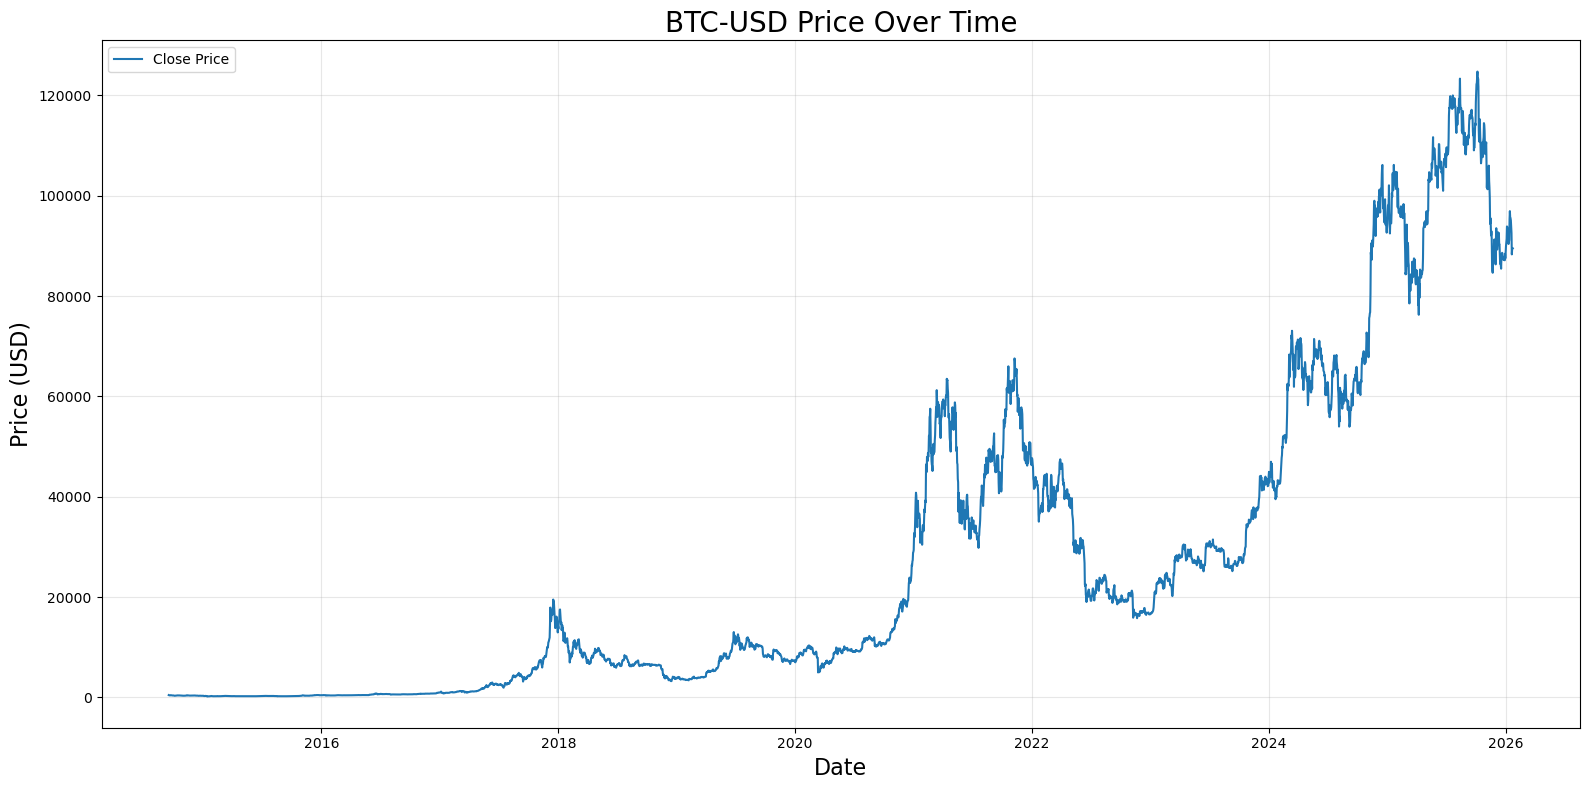

In [5]:


plt.figure(figsize=(16,8))
plt.plot(df.index, df["Close"], label="Close Price")
plt.title(f"{ticker} Price Over Time", fontsize=20)
plt.xlabel("Date", fontsize=16)
plt.ylabel("Price (USD)", fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



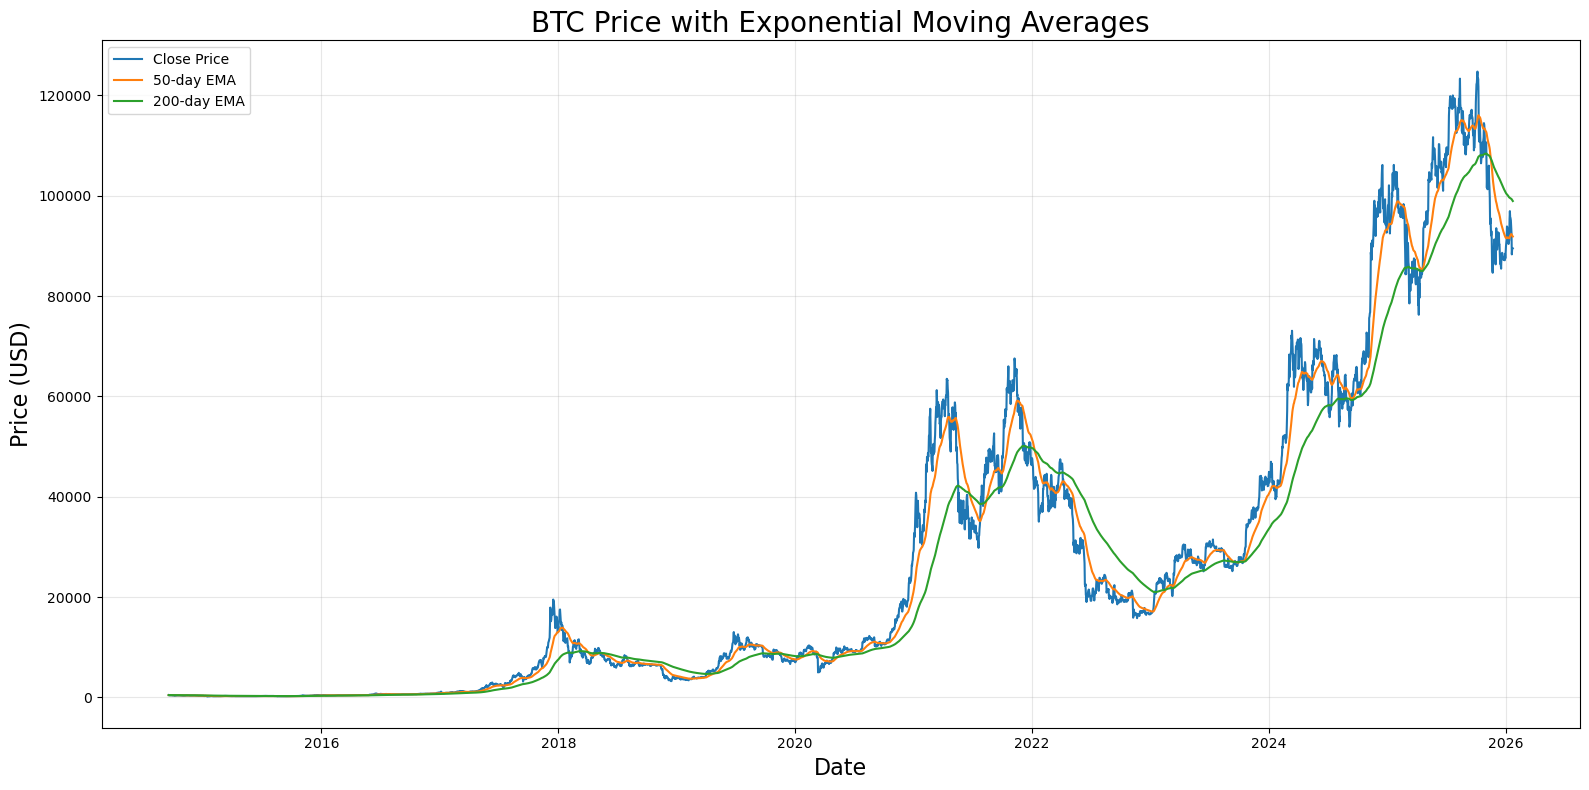

In [6]:
import matplotlib.pyplot as plt

# Add EMAs
df["EMA_50"] = df["Close"].ewm(span=50, adjust=False).mean()
df["EMA_200"] = df["Close"].ewm(span=200, adjust=False).mean()

plt.figure(figsize=(16,8))
plt.plot(df.index, df["Close"], label="Close Price")
plt.plot(df.index, df["EMA_50"], label="50-day EMA")
plt.plot(df.index, df["EMA_200"], label="200-day EMA")
plt.title("BTC Price with Exponential Moving Averages", fontsize=20)
plt.xlabel("Date", fontsize=16)
plt.ylabel("Price (USD)", fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### Calculating % Changed in each Trading Session


In [7]:
df['Percentage Change'] = df.Close.pct_change()
df[['Close', 'Percentage Change']]

Price,Close,Percentage Change
Ticker,BTC-USD,
Date,,
2014-09-17,457.334015,NaN
2014-09-18,424.440002,-0.071926
2014-09-19,394.795990,-0.069843
2014-09-20,408.903992,0.035735
2014-09-21,398.821014,-0.024659
...,...,...
2026-01-19,92553.593750,-0.011543
2026-01-20,88310.906250,-0.045840


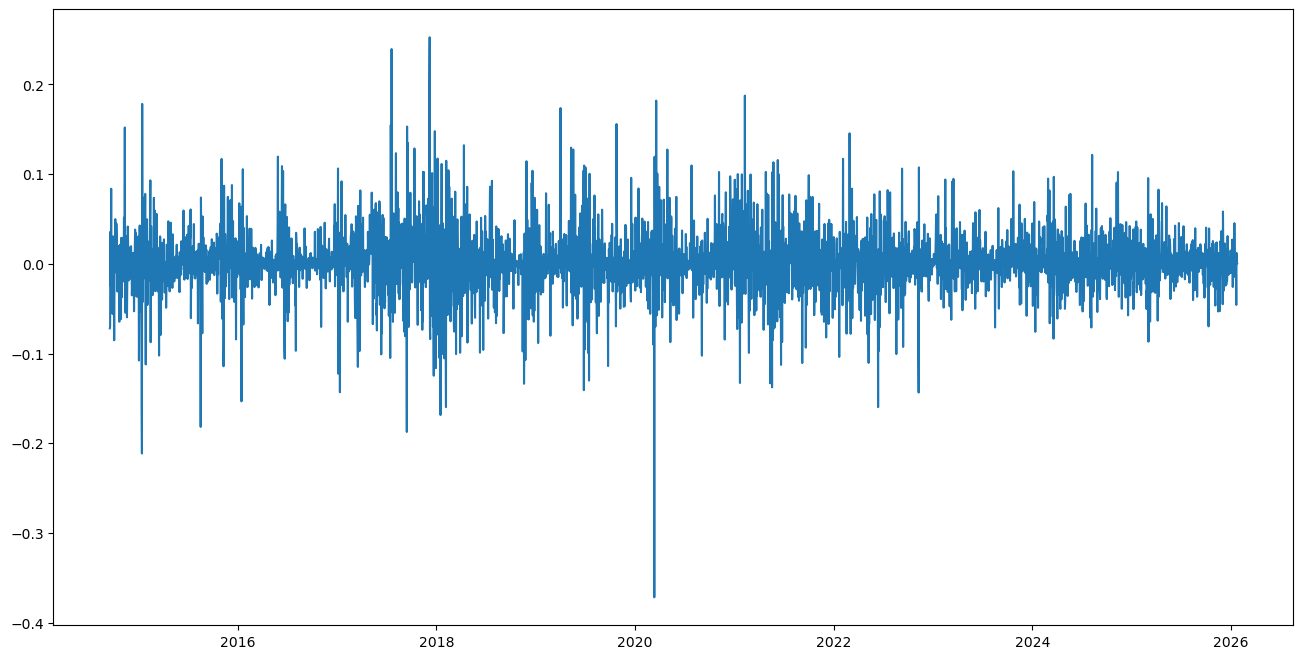

In [8]:
plt.figure(figsize=(16,8))
plt.plot(df['Percentage Change'])

### 4.Data Preprocessing

In [9]:
df.shape        

(4147, 8)

In [10]:
# Splitting the data into training and testing sets
training_data = pd.DataFrame(df.Close[0:int(len(df)*0.70)])
testing_data = pd.DataFrame(df.Close[int(len(df)*0.70): int(len(df))])


print(training_data)
print(testing_data)

Ticker           BTC-USD
Date                    
2014-09-17    457.334015
2014-09-18    424.440002
2014-09-19    394.795990
2014-09-20    408.903992
2014-09-21    398.821014
...                  ...
2022-08-23  21528.087891
2022-08-24  21395.019531
2022-08-25  21600.904297
2022-08-26  20260.019531
2022-08-27  20041.738281

[2902 rows x 1 columns]
Ticker           BTC-USD
Date                    
2022-08-28  19616.814453
2022-08-29  20297.994141
2022-08-30  19796.808594
2022-08-31  20049.763672
2022-09-01  20127.140625
...                  ...
2026-01-19  92553.593750
2026-01-20  88310.906250
2026-01-21  89376.960938
2026-01-22  89462.453125
2026-01-23  89503.875000

[1245 rows x 1 columns]


In [11]:
# Scaling down the data between 0 and 1

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

training_data_array = scaler.fit_transform(training_data)
training_data_array

type(training_data_array)
training_data_array.shape

(2902, 1)

#### 5.Sequence Creation


In [12]:
x_train = []
y_train = []

for i in range(100, training_data_array.shape[0]):
    x_train.append(training_data_array[i-100: i])
    y_train.append(training_data_array[i, 0])
    
x_train, y_train = np.array(x_train), np.array(y_train)
x_train.shape, y_train.shape

((2802, 100, 1), (2802,))

#### 6.Model Building


In [13]:
import tensorflow as tf 
print(tf.__version__)

2.20.0


In [14]:
# ML Model
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

model = Sequential()

model.add(Input(shape=(100, 1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(units=1))


#### 7.Model Training

In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 348,101 (1.33 MB)

 Trainable params: 116,033 (453.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 232,068 (906.52 KB)

In [ ]:
# Save the trained model
model.save("stock_prediction_model.keras")

#### 8.Preparing Test Data

In [19]:
past_100_days = testing_data.tail(100)

past_100_days

Ticker,BTC-USD
Date,
2025-10-16,108186.039062
2025-10-17,106467.789062
2025-10-18,107198.265625
2025-10-19,108666.710938
2025-10-20,110588.929688
...,...
2026-01-19,92553.593750
2026-01-20,88310.906250
2026-01-21,89376.960938


In [20]:
final_df = pd.concat([past_100_days, testing_data], ignore_index=True)
final_df

Ticker,BTC-USD
0,108186.039062
1,106467.789062
2,107198.265625
3,108666.710938
4,110588.929688
...,...
1340,92553.593750
1341,88310.906250
1342,89376.960938
1343,89462.453125


In [22]:
input_data = scaler.transform(final_df)
input_data.shape

(1345, 1)

In [24]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])
    

In [25]:
x_test, y_test = np.array(x_test), np.array(y_test)


In [28]:
x_test[0].shape

(100, 1)

#### 9.Making Predictons

In [29]:
y_predicted = model.predict(x_test)


39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step


In [30]:
y_predicted

array([[1.286426 ],
       [1.2188218],
       [1.1221919],
       ...,
       [1.3072282],
       [1.3010598],
       [1.2938439]], dtype=float32)

In [31]:
y_test

array([0.28845644, 0.29856465, 0.29112742, ..., 1.32364662, 1.32491526,
       1.32552993])

In [32]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()


In [33]:
y_predicted

array([86868.7  , 82312.945, 75801.18 , ..., 88270.54 , 87854.87 ,
       87368.586], dtype=float32)

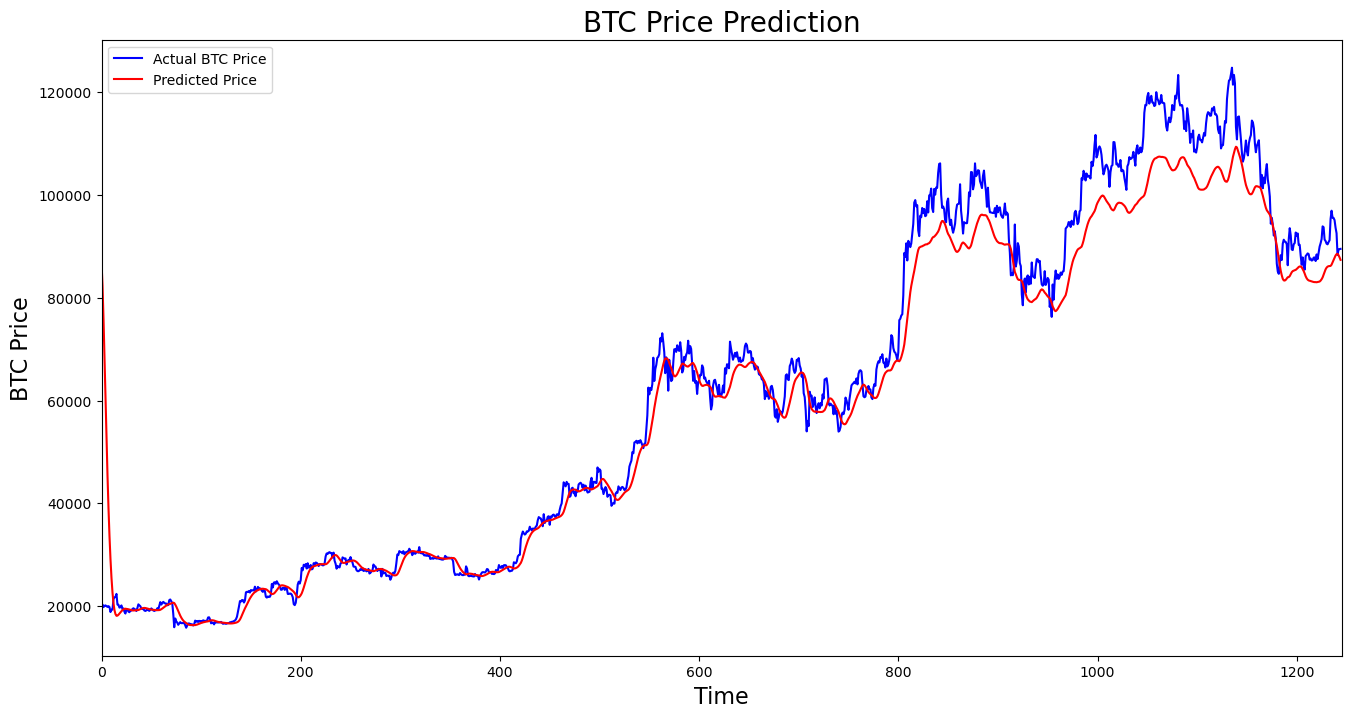

<Figure size 640x480 with 0 Axes>

In [35]:
plt.figure(figsize=(16,8))
plt.plot(y_test, color='blue', label='Actual BTC Price')
plt.plot(y_predicted, color='red', label='Predicted Price')
plt.title('BTC Price Prediction', fontsize=20)
plt.xlabel('Time', fontsize=16)
plt.ylabel('BTC Price', fontsize=16)
plt.legend()
plt.xlim(0, len(y_test))
plt.show()
plt.tight_layout()


#### 10.Model Evaluation


In [39]:
# Mean Squared Error
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_predicted)
print("Mean Squared Error:", mse)

Mean Squared Error: 43305257.87118392


In [40]:
# Root Mean squared Error (RMSE)
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)



Root Mean Squared Error: 6580.673056092661


In [41]:
# R-Squared Score
r2 = r2_score(y_test, y_predicted)
print("R-Squared Score:", r2)

R-Squared Score: 0.9609358401199596
